In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Monthly Car Sales dataset directly from the web
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(url)

# Display the first few rows and basic info
print("--- Dataset Info ---")
print(df.info())
print("\n--- First 5 Rows ---")
display(df.head())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Month   108 non-null    str  
 1   Sales   108 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.6 KB
None

--- First 5 Rows ---


,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


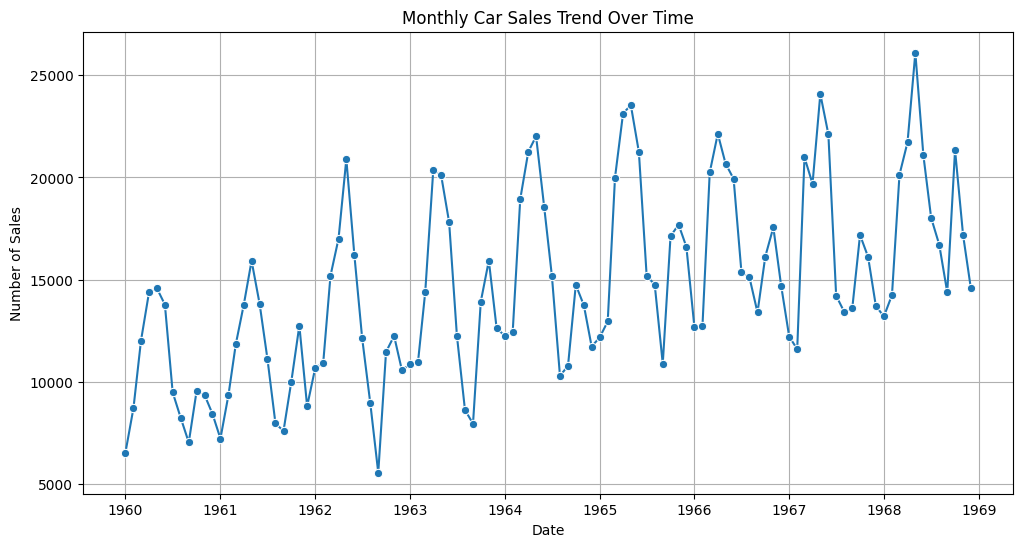

In [2]:
# 1. Handle missing values (dropping any if they exist)
df = df.dropna()

# 2. Convert 'Month' column to appropriate datetime format
df['Month'] = pd.to_datetime(df['Month'])

# 3. Sort the dataset chronologically (Crucial for time-series)
df = df.sort_values('Month')

# 4. Extract relevant features
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month
# Note: We skip 'Day' because this is strictly monthly data (every day defaults to the 1st)

# Visualize the historical sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Sales', data=df, marker='o')
plt.title('Monthly Car Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.grid(True)
plt.show()

In [3]:
# Define features (X) and target variable (y)
X = df[['Year', 'Month_Num']] 
y = df['Sales'] 

# Split the data sequentially (80% training, 20% testing)
# shuffle=False is critical to prevent data leakage from the future into the past
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the unseen testing data
predictions = model.predict(X_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (86, 2)
Testing data shape: (22, 2)


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 3184.93
Root Mean Squared Error (RMSE): 3686.84
R² Score: 0.0396


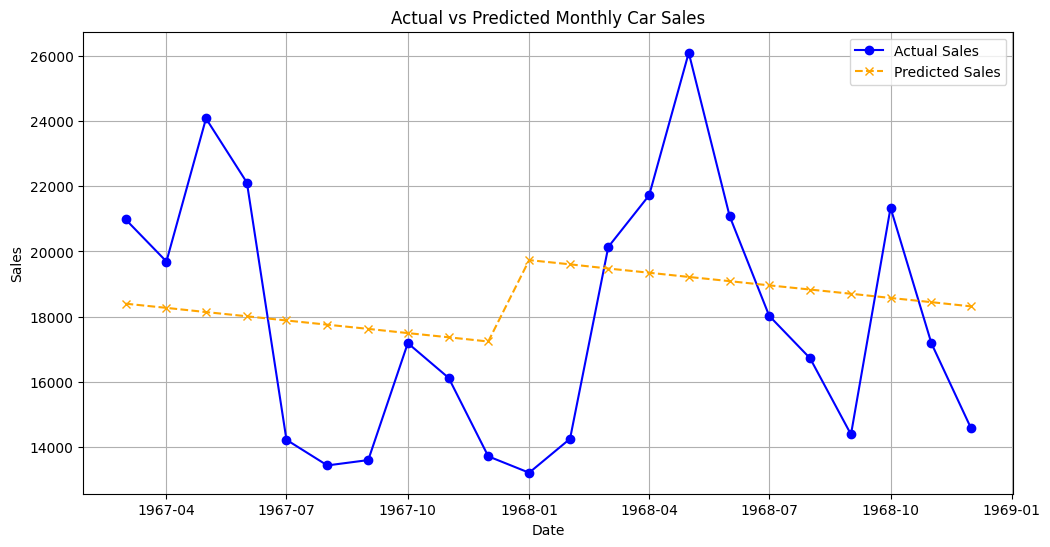

In [4]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Visualize the actual vs predicted sales
plt.figure(figsize=(12, 6))
# Plot actual sales for the test period
plt.plot(df['Month'].iloc[y_test.index], y_test, label='Actual Sales', color='blue', marker='o')
# Plot predicted sales for the test period
plt.plot(df['Month'].iloc[y_test.index], predictions, label='Predicted Sales', color='orange', linestyle='--', marker='x')

plt.title('Actual vs Predicted Monthly Car Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

Analysis and Observations:

Data Trends: The exploratory data analysis reveals a clear, repeating seasonality in car sales, with noticeable peaks occurring at similar times each year, along with an overall upward trend in sales volume over the dataset's lifespan.

Model Performance: The Linear Regression model was able to capture the general upward trajectory of the sales over time using just the extracted Year and Month_Num features.

Limitations & Future Work: While Linear Regression provides a solid baseline, it struggles to perfectly map out the sharp seasonal peaks and valleys. Because time-series data relies heavily on rolling averages and prior data points (lag), future iterations of this case study would benefit from using models specifically designed for time-series forecasting, such as ARIMA (AutoRegressive Integrated Moving Average) or Facebook Prophet.